Applicare un modello di deep learning con keras ai dataset titanic e house pricing

Attenzione a gestire correttamente l'ultimo layer

Provare poi anche numeri di layer e di neuroni diversi

Attenzione le reti neurali non gestiscono da sole i valori nulli come fa xgboost

## Import Librerie

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.layers import BatchNormalization
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

## Caricamento dataset

Controllo valori mancanti

In [2]:
df = sns.load_dataset('titanic')
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Gestione valori nulli e rimozione colonne ridondanti

In [3]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df = df.drop(columns=['deck', 'alive', 'class', 'embark_town','alone', 'adult_male','who'])
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## Feature engineering

Creazione nuove variabili che aiutano il modello

In [4]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['age_group'] = pd.cut(df['age'], bins=[0,12,18,35,60,100])
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

## Conversione variabili categoriche

Trasformazione di variabili categoriche in variabili numeriche binarie (One-hot encoding)

In [5]:
df = pd.get_dummies(df, drop_first=True)

## Separazione Input/Target

In [6]:
X = df.drop(columns='survived')
y = df['survived']

## Suddivisione train/test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Normalizzazione feature

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Architettura rete neurale

In [9]:
'''
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))


model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))


model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))'''

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

C:\Users\veryv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 128 (512.00 B)

## Configurazione processo apprendimento

In [11]:
opt = Adam(learning_rate=0.0005)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Controllo training

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

## Training modello

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0:1, 1:1.3}
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6063 - loss: 0.8874 - val_accuracy: 0.6434 - val_loss: 0.6163 - learning_rate: 5.0000e-04
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6450 - loss: 0.7915 - val_accuracy: 0.7133 - val_loss: 0.6006 - learning_rate: 5.0000e-04
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7135 - loss: 0.6943 - val_accuracy: 0.7413 - val_loss: 0.5873 - learning_rate: 5.0000e-04
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7030 - loss: 0.6726 - val_accuracy: 0.7832 - val_loss: 0.5729 - learning_rate: 5.0000e-04
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7452 - loss: 0.6466 - val_accuracy: 0.7972 - val_loss: 0.5587 - learning_rate: 5.0000e-04
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7399 - loss: 0.6383 - val_accuracy: 0.7972 - val_loss: 0.5475 - learning_rate: 5.0000e-04
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 

## Visualizzazione allenamento

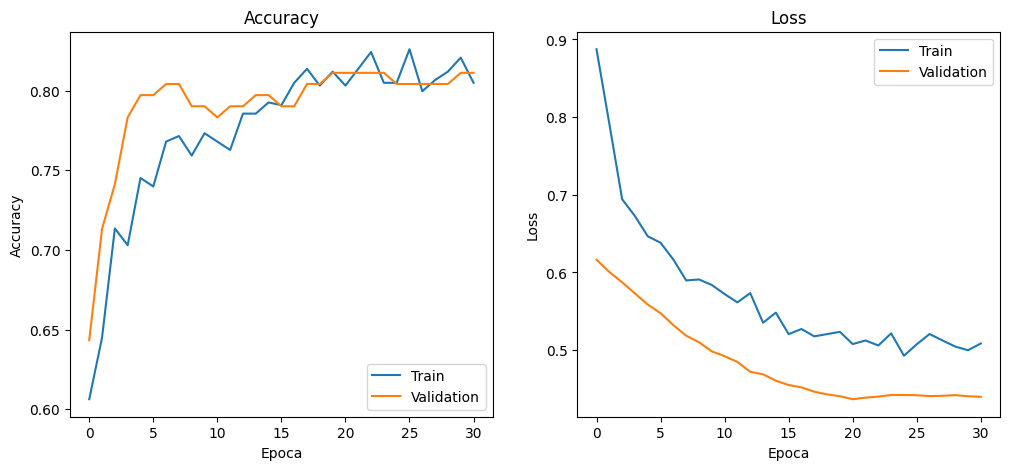

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Valutazione finale modello

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7933 - loss: 0.4579
Test loss: 0.4578644335269928
Test accuracy: 0.7932960987091064
